In [1]:
import numpy as np
import torch.nn as nn
import torch
from tqdm import tqdm
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. 理论基础与数据集构建 (Visualize Datasets)

**Flow Matching (流匹配)** 本质上是在构建一个常微分方程 (ODE) 对应的连续标准化流 (CNF)。我们希望找到一个时间依赖的速度场 (Time-dependent Vector Field) $v_\theta(x, t)$，用来将一个易于采样的**源分布**随着时间 $t$ 平滑地迁移到复杂的**目标分布**。

- **源分布**，通常为标准高斯分布，记为 $x_0 \sim p_0(x)$，对应的时刻是 $t=0$。
- **目标分布**，训练数据的真实分布，记为 $x_1 \sim p_1(x)$ (这里的二维棋盘格数据)，对应 $t=1$。

接下来我们先构建这两个基础数据集。

In [3]:
def make_gaussian(batch_size):
    # 从2D的标准高斯分布(均值为0, 标准差为1)中采样，作为我们的源分布 (p0)
    return torch.randn(batch_size, 2)

def make_checkerboard(batch_size):
    # 构建2D的棋盘格分布 (Checkerboard Dataset)，作为我们的目标分布 (p1)
    
    # 步骤1: 均匀采样 x 坐标，范围在 [-2, 2) 之间
    x1 = torch.rand(batch_size) * 4 - 2

    # 步骤2: 采样 y 坐标的基础值
    # 先从 [0, 1) 中产生均匀分布，再随机减去 0 或 2 (借助 torch.randint)
    # 这样 y 的基础值就被打散在了不连续的区间内
    x2_ = torch.rand(batch_size) - torch.randint(high=2, size=(batch_size, )) * 2

    # 步骤3: 核心技巧，依据 x1 所在的区间是奇数还是偶数，给 y 加上垂直偏移
    # 从而创造出棋盘格中交错的格点效果
    x2 = x2_ + (torch.floor(x1) % 2)

    # 将 x1 和 x2 组合为二维坐标，并做一个缩放放大
    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45

    return data.float()

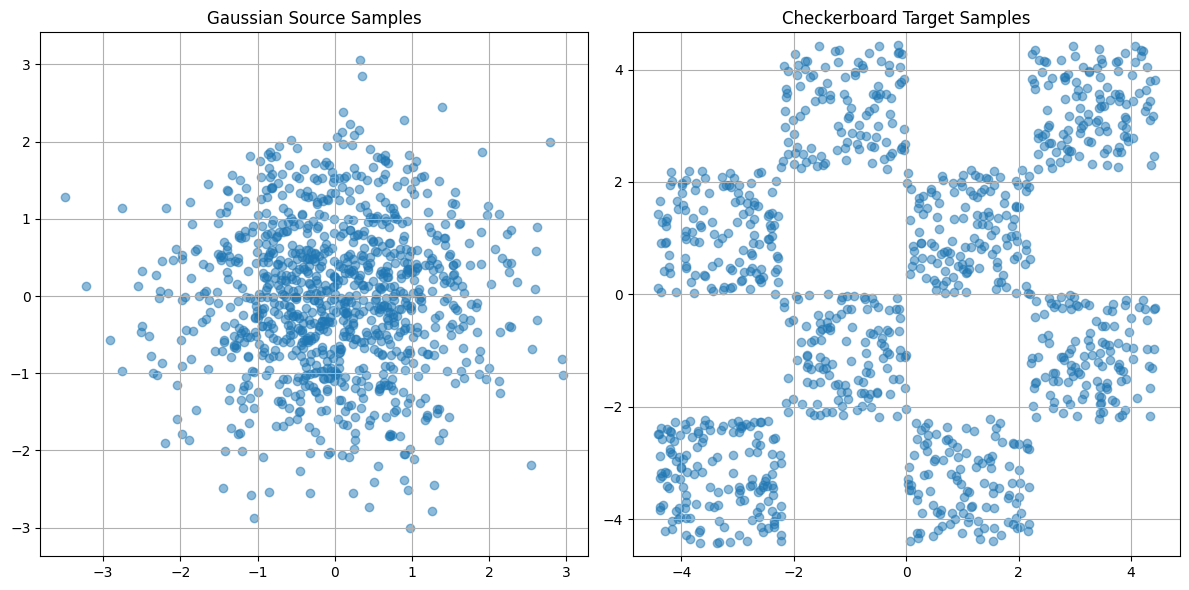

In [4]:
# Sample points
gaussian_samples = make_gaussian(1000)
checkerboard_samples = make_checkerboard(1000)

# Plot both
plt.figure(figsize=(12, 6))

# Plot Gaussian source
plt.subplot(1, 2, 1)
plt.scatter(gaussian_samples[:, 0], gaussian_samples[:, 1], alpha=0.5)
plt.title("Gaussian Source Samples")
plt.axis("equal")
plt.grid(True)

# Plot Checkerboard target
plt.subplot(1, 2, 2)
plt.scatter(checkerboard_samples[:, 0], checkerboard_samples[:, 1], alpha=0.5)
plt.title("Checkerboard Target Samples")
plt.axis("equal")
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. 构建预测速度场的神经网络

为了驱动采样从源端流动到目标端，我们需要拟合速度场 $v(x,t)$。
神经网络模型 $v_\theta(x, t)$ 的任务就是根据当前的状态变量 $x$ 和时间步骤 $t$，预估当前的“**运动速度**”。由于 $t$ 是一维标量，我们通常会使用时间嵌入 (Time Embedding) 技术将其投影到高维特征空间，再与 $x$ 一同输入给多层感知机 (MLP)。

In [5]:
class FlowModel(nn.Module):
  # 这是一个用来拟合时间依赖速度场 f(x, t) 的神经网络
  def __init__(self, input_dim=2, time_embed_dim=64):
    super().__init__()

    # 小型 MLP，用于将一维的时间 t 映射到一个高维特征空间 (Time Embedding)
    self.time_embed = nn.Sequential(
        nn.Linear(1, time_embed_dim),
        nn.SiLU(),                     # 激活函数: Sigmoid Linear Unit
        nn.Linear(time_embed_dim, time_embed_dim)
    )

    # 主网络模块，输入是空间坐标 x 与时间嵌入(t_embed)的拼接，输出预测的速度矢量
    self.net = nn.Sequential(
        nn.Linear(input_dim + time_embed_dim, 128),  # 拼接后的维度
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, 128),
        nn.SiLU(),
        nn.Linear(128, input_dim)  # 输出对应的速度，其维度与输入的空间坐标x一致
    )

  def forward(self, x, t):
    # 【输入尺寸】
    # x: [batch_size, input_dim]
    # t: [batch_size, 1] 
    
    # 1. 抽取时间 t 的高维特征表达
    t_embed = self.time_embed(t)

    # 2. 将空间坐标 x 和 时间的特征表达 拼接在最后一个维度上
    xt = torch.cat([x, t_embed], dim=-1)

    # 3. 前向传播预测该时刻 (x, t) 点处的速度场向量
    return self.net(xt)

# 3. 流匹配条件代价函数 (Flow Matching Loss)

相较于扩散模型(Diffusion)，Flow Matching 中构建了一条通往目标数据的连续直线轨迹：
在 $t \in [0, 1]$ 之间，我们将源数据和目标数据作**线性插值**：
$$ x_t = (1-t)x_0 + t x_1 $$

这就意味着该点的理论目标速度 (导数 $\frac{d}{dt}x_t$) 是一个不随时间变化的常数：
$$ u_t(x_t | x_1) = x_1 - x_0 $$

损失函数的核心就是用均方误差约束神经网络预测的速度 $v_\theta(x_t, t)$ 去逼近这条直线轨迹的目标速度：
$$ \mathcal{L}(\theta) = \mathbb{E}_{t, p_0(x_0), p_1(x_1)} \left[ \left\| v_\theta(x_t, t) - (x_1 - x_0) \right\|^2 \right] $$

In [6]:
def flow_matching_loss(model, x0, x1, t):
  # 1. 计算每个 t 时刻轨迹在空间中的线性插值点 x_t
  # 当 t=0 时为 x0，当 t=1 时为 x1
  xt = (1 - t) * x0 + t * x1

  # 2. 计算对应插值的真实目标速度 (Ground Truth Velocity)
  # 因为是简单的直线插值，所以速度是不随 t 变化的向量: x1 - x0
  v_target = x1 - x0

  # 3. 使用神经网络模型，传入(x_t, t)，预测此刻的速度 v_pred
  v_pred = model(xt, t)

  # 4. 计算预测速度和目标速度之间的均方误差损失(MSE)，并求当前批次的平均值
  return ((v_pred - v_target) ** 2).mean()

# 4. 采样与训练循环

In [ ]:
def sample_target(batch_size):
    # 和上文的数据构建类似，采样目标数据特征
    # [步骤 1] 针对横向坐标 x1 进行均匀采样，边界为 [-2, 2)
    x1 = torch.rand(batch_size) * 4 - 2

    # [步骤 2] 构建纵向坐标特征
    # 使用 rand 发生 [0, 1) 值，减去离散选择的 0 或 2 (随机取一)
    x2_ = torch.rand(batch_size) - torch.randint(high=2, size=(batch_size, )) * 2

    # [步骤 3] 为制造间隔交叉网格效果的纵坐标位移，由当前对应横轴落点所在区域判断
    x2 = x2_ + (torch.floor(x1) % 2)

    # 组装两个层面的张量向量，按给定缩放要求放大特征结构
    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45

    # 修正 UserWarning，直接通过 clone().detach() 转换类型
    return data.clone().detach().to(torch.float32)

In [8]:
def sample_source(batch_size):
    # 抽取服从 2D 标准正态分布 (0均值，1标准差) 的初始化点群
    return torch.randn(batch_size, 2)

# Training Loop

In [16]:
num_steps = 10000 
batch_size = 512
losses = []

# 初始化网络和推入所需设备
model = FlowModel().to(device)
# 采用 Adam 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

for step in tqdm(range(num_steps)):
  # 取出一个 batch 的源分布数据 (p0)
  x0 = sample_source(batch_size).to(device)
  # 取出一个 batch 的目标分布数据 (p1)
  x1 = sample_target(batch_size).to(device)
  
  # 随机生成插值的时间 t ，范围在 [0, 1] 之间
  # 形状为 (batch_size, 1) 以便与 x_t 广播计算
  t = torch.rand(batch_size, 1).to(device) 

  # 前向计算流匹配损失
  loss = flow_matching_loss(model, x0, x1, t)

  # 反向传播和优化
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  losses.append(loss.item())

  if step % 1000 == 0:
    print(f"Step {step} | Loss: {loss.item():.4f}")

  0%|          | 0/10000 [00:00<?, ?it/s]/tmp/ipykernel_3689729/2955151855.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(data, dtype=torch.float32)
  2%|▏         | 211/10000 [00:00<00:09, 1050.49it/s]

Step 0 | Loss: 7.7481


 12%|█▏        | 1152/10000 [00:01<00:08, 1037.94it/s]

Step 1000 | Loss: 3.8151


 21%|██        | 2108/10000 [00:02<00:07, 1037.73it/s]

...

 82%|████████▏ | 8216/10000 [00:07<00:01, 1087.09it/s]

Step 8000 | Loss: 3.7101


 92%|█████████▏| 9165/10000 [00:08<00:00, 1031.39it/s]

Step 9000 | Loss: 3.7278


100%|██████████| 10000/10000 [00:09<00:00, 1039.67it/s]


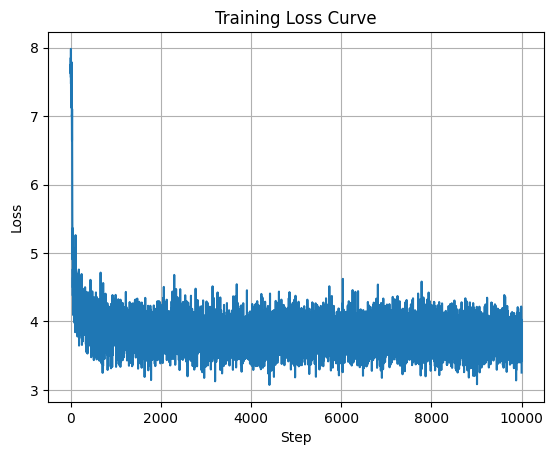

In [17]:
# Plot after training
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [11]:
def plot_velocity_row(model, t_values=[0.0, 0.25, 0.5, 0.75, 1.0], grid_size=20):
    # 训练后为了可视化模型学习出的向量场，在空间中铺设一系列参考点并预测瞬时速度大小方向
    model.eval()
    with torch.no_grad():
        # 配置参考点云和画板
        fig, axes = plt.subplots(1, len(t_values), figsize=(4 * len(t_values), 4))
        
        # 在二维空间内均匀铺设 20x20 的网格参考点
        x = np.linspace(-4, 4, grid_size)
        y = np.linspace(-4, 4, grid_size)
        xx, yy = np.meshgrid(x, y)
        xy = np.stack([xx.flatten(), yy.flatten()], axis=1)
        xt = torch.tensor(xy, dtype=torch.float32).to(device)

        # 遍历需要查看的时间点，分别画出网格上的向量箭头 (Quiver图)
        for i, t_val in enumerate(t_values):
            # 铺开对应的 t 用于对应同一时间下的所有点推理 
            tt = torch.full((xt.shape[0], 1), t_val, dtype=torch.float32).to(device)

            # 呼叫模型推演出预测的速度阵 v (2维度方向矢量)
            v = model(xt, tt).cpu().numpy()

            # 以网格位置起点，用箭头标出其推算出来的预测速度与方向
            ax = axes[i]
            ax.quiver(xx, yy,
                      v[:, 0].reshape(grid_size, grid_size),
                      v[:, 1].reshape(grid_size, grid_size),
                      scale=20)
            ax.set_title(f"t = {t_val}")
            ax.axis("equal")
            ax.grid(True)

        plt.tight_layout()
        plt.show()

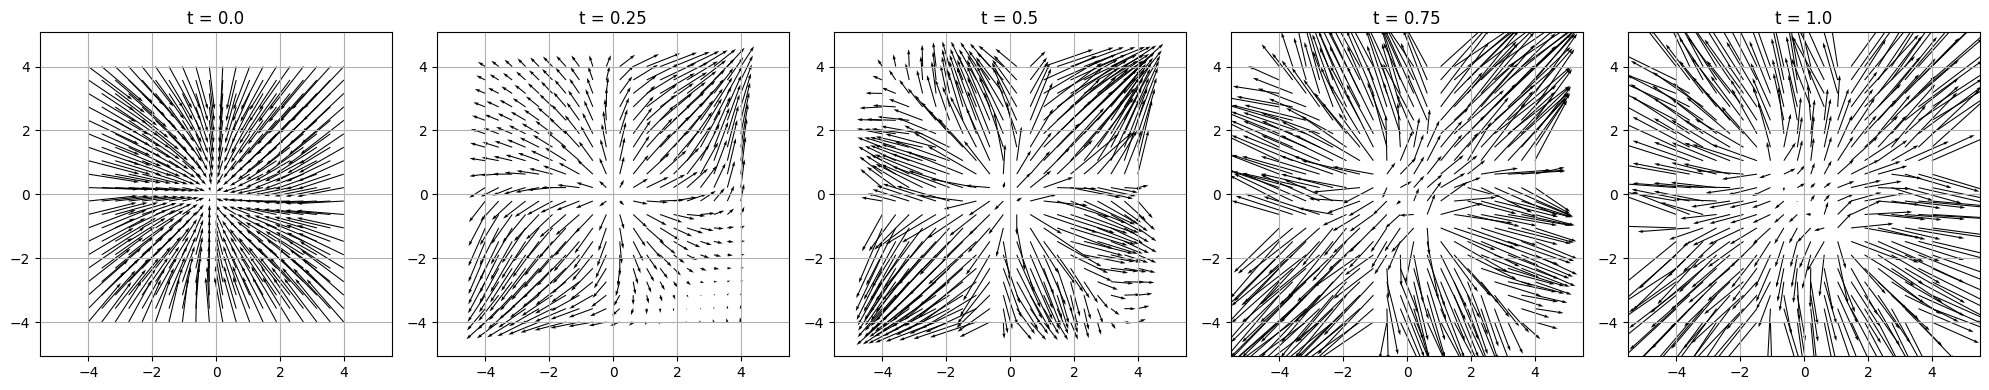

In [12]:
plot_velocity_row(model)

# 5. 推理生成阶段：求解ODE (ODE Integration)

至此，我们的模型已经拟合好了连接 $p_0$ 和 $p_1$ 的速度向量场 $v_\theta(x, t)$。
为了生成新的目标数据样本，我们首先从源分布（高斯）中抽取一些点 $x_0$，作为 ODE 系统的**初始条件 (Initial Values)**。然后我们沿着时间轴从 $t = 0$ 积分到 $t = 1$：
$$ x_1 = x_0 + \int_{0}^{1} v_\theta(x_t, t) dt $$

通过现成的常微分方程数值求解器（本代码使用了 `scipy.integrate.solve_ivp`），我们可以获得经过时间 $t=1$ 演变后的最终值，这就是网络生成的目标样本。

In [13]:
def sample_flow(model, x0, t_span=(0, 1)):
    """
    通过积分学习到的向量场 ODE，将先验分布点 x0 推演生成出属于目标分布的样本。
    """
    def ode_func(t, x):
        # 内部定义的 ODE 导数函数，需符合 solve_ivp 的输入接口：func(t, y)
        # 将传入的 numpy 形式的 x 和 t 转为符合模型需要的 tensor 格式
        x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(device)
        t_tensor = torch.tensor([[t]], dtype=torch.float32).to(device)

        # 进行纯前向推理（防止跟踪梯度），获取速度矢量
        with torch.no_grad():
            v = model(x_tensor, t_tensor)

        # 返回需要被积分项的 numpy 数组，即 dx/dt = v
        return v.squeeze(0).cpu().numpy()

    # 使用 Scipy 的 ODE 求解器，从 t=0 滑动到 t=1
    # x0 为积分的初始值
    sol = solve_ivp(ode_func, t_span, x0.cpu().numpy(), t_eval=[t_span[1]])

    # 提取时间走到终点 (即 t=1) 时的空间状态结果
    return sol.y[:, -1]

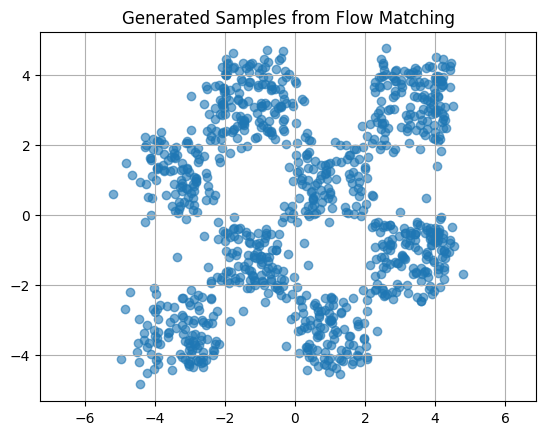

In [14]:
samples = []

# 从作为起始/先验的 p0 分布 (标准正态分布) 中采样 1000 个随机起始点 x0
x0 = sample_source(1000).to(device)

# 遍历每一个初值点，沿着学习好的向量场进行“推动”积分，获取分布于 p1 空间的样本
for x in x0:
    with torch.no_grad():
        x = x.to(device)
        # 求解从 t=0 到 t=1 积分过程：x0 -> x1_hat (生成点)
        x1_hat = sample_flow(model, x, t_span=(0, 1)) 
        samples.append(x1_hat)

# 转置/整形为需要的绘图数组结构
samples = np.array(samples)

# 绘制生成出的样本点云（应当和目标 Checkerboard 图案高度相似）
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.6)
plt.title("Generated Samples from Flow Matching")
plt.axis("equal")
plt.grid(True)
plt.show()

/tmp/ipykernel_3689729/2955151855.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(data, dtype=torch.float32)


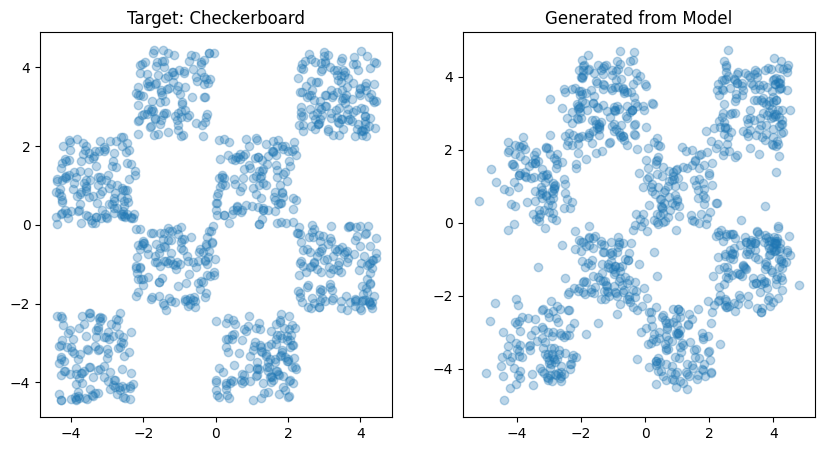

In [15]:
# 为了对比，我们将模型在 ODE 中采样生成的样本 (生成样本) 和直接定义的真实分布 (目标样本) 放在一起直观显示
real = sample_target(1000)
gen = np.array(samples)

plt.figure(figsize=(10, 5))

# 真实棋盘格作为参考
plt.subplot(1, 2, 1)
plt.scatter(real[:, 0], real[:, 1], alpha=0.3)
plt.title("Target: Checkerboard")

# 我们从标准正态分布出发通过 Flow 模型积分最终所达到的样点群作为对比
plt.subplot(1, 2, 2)
plt.scatter(gen[:, 0], gen[:, 1], alpha=0.3)
plt.title("Generated from Model")

plt.show()